# lec03-dev

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("svg")

# DSC 80 preferred styles
pio.templates["dsc80"] = go.layout.Template(
    layout=dict(
        margin=dict(l=30, r=30, t=30, b=30),
        autosize=True,
        xaxis=dict(showgrid=True),
        yaxis=dict(showgrid=True),
        title=dict(x=0.5, xanchor="center"),
    )
)
pio.templates.default = "simple_white+dsc80"

import warnings
warnings.simplefilter('ignore')

import datetime

from scipy.optimize import minimize

In [2]:
vals = [1, 2, 3, 14]

In [3]:
!ls ../

dev       imgs      lec03.md  lec03.pdf


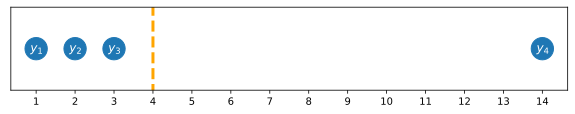

In [4]:
plt.figure(figsize=(10, 1.5), dpi=200)
plt.scatter(vals, [0] * 4, s=500)
plt.xticks(range(1, 15))
plt.ylim(-0.2, 0.2)
for i, val in enumerate(vals):
    plt.annotate(fr'$y_{i+1}$', (val-0.15, -0.015), fontsize=12, color='white', font='Arial')
plt.plot([4, 4], [-0.3, 0.3], linewidth=3, linestyle='dashed', color='orange')
# plt.annotate('$h$', (4-0.1, -0.02), fontsize=12, color='white', font='Arial')
plt.yticks([])
plt.savefig('../imgs/outlier-line.png', dpi=200, bbox_inches='tight')

In [5]:
px.scatter

<function plotly.express._chart_types.scatter(data_frame=None, x=None, y=None, color=None, symbol=None, size=None, hover_name=None, hover_data=None, custom_data=None, text=None, facet_row=None, facet_col=None, facet_col_wrap=0, facet_row_spacing=None, facet_col_spacing=None, error_x=None, error_x_minus=None, error_y=None, error_y_minus=None, animation_frame=None, animation_group=None, category_orders=None, labels=None, orientation=None, color_discrete_sequence=None, color_discrete_map=None, color_continuous_scale=None, range_color=None, color_continuous_midpoint=None, symbol_sequence=None, symbol_map=None, opacity=None, size_max=None, marginal_x=None, marginal_y=None, trendline=None, trendline_options=None, trendline_color_override=None, trendline_scope='trace', log_x=False, log_y=False, range_x=None, range_y=None, render_mode='auto', title=None, template=None, width=None, height=None) -> plotly.graph_objs._figure.Figure>

([], [])

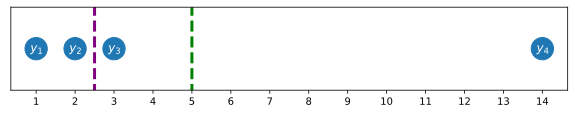

In [6]:
plt.figure(figsize=(10, 1.5), dpi=200)
plt.scatter(vals, [0] * 4, s=500)
plt.xticks(range(1, 15))
plt.ylim(-0.2, 0.2)
for i, val in enumerate(vals):
    plt.annotate(fr'$y_{i+1}$', (val-0.15, -0.015), fontsize=12, color='white', font='Arial')
plt.plot([2.5, 2.5], [-0.3, 0.3], linewidth=3, linestyle='dashed', color='purple')
plt.plot([5, 5], [-0.3, 0.3], linewidth=3, linestyle='dashed', color='green')
plt.annotate('$h$', (4-0.1, -0.02), fontsize=12, color='white', font='Arial')
plt.yticks([])
# plt.savefig('../imgs/four-dots-median-mean.png', dpi=200, bbox_inches='tight')

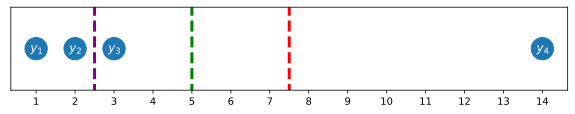

In [7]:
plt.figure(figsize=(10, 1.5), dpi=200)
plt.scatter(vals, [0] * 4, s=500)
plt.xticks(range(1, 15))
plt.ylim(-0.2, 0.2)
for i, val in enumerate(vals):
    plt.annotate(fr'$y_{i+1}$', (val-0.15, -0.015), fontsize=12, color='white', font='Arial')
plt.plot([2.5, 2.5], [-0.3, 0.3], linewidth=3, linestyle='dashed', color='purple')
plt.plot([5, 5], [-0.3, 0.3], linewidth=3, linestyle='dashed', color='green')
plt.plot([7.5, 7.5], [-0.3, 0.3], linewidth=3, linestyle='dashed', color='red')
plt.annotate('$h$', (4-0.1, -0.02), fontsize=12, color='white', font='Arial')
plt.yticks([])
plt.savefig('../imgs/four-dots-median-mean-midrange.png', dpi=200, bbox_inches='tight')

In [75]:
vals = np.array([1, 2, 3, 14])

In [8]:
def best_h(deg):
    def er(h):
        return np.mean(np.abs(vals - h) ** deg)
    return minimize(er, x0=[0])['x'][0]

In [ ]:
hspace = np.arange(1, 41)
out = [best_h(i) for i in hspace]

fig = px.line(x=hspace, y=out)
fig.update_xaxes(title='$p$')
fig.update_yaxes(title='$h^*$', range=[1, 8.5])
fig.update_layout(width=400, height=400, title=r'')

In [10]:
px.line

<function plotly.express._chart_types.line(data_frame=None, x=None, y=None, line_group=None, color=None, line_dash=None, symbol=None, hover_name=None, hover_data=None, custom_data=None, text=None, facet_row=None, facet_col=None, facet_col_wrap=0, facet_row_spacing=None, facet_col_spacing=None, error_x=None, error_x_minus=None, error_y=None, error_y_minus=None, animation_frame=None, animation_group=None, category_orders=None, labels=None, orientation=None, color_discrete_sequence=None, color_discrete_map=None, line_dash_sequence=None, line_dash_map=None, symbol_sequence=None, symbol_map=None, markers=False, log_x=False, log_y=False, range_x=None, range_y=None, line_shape=None, render_mode='auto', title=None, template=None, width=None, height=None) -> plotly.graph_objs._figure.Figure>

In [11]:
for i in range(1, 101):
    print(i, np.round(best_h(i), 5))

1 2.0
2 5.0
3 6.34408
4 6.83428
5 7.07454
6 7.21154
7 7.29684
8 7.35304
9 7.39154
10 7.4187
11 7.43828
12 7.45266
13 7.46337
14 7.47145
15 7.4776
16 7.48233
17 7.486
18 7.48886
19 7.4911
20 7.49287
21 7.49427
22 7.49538
23 7.49627
24 7.49698
25 7.49755
26 7.49801
27 7.49838
28 7.49868
29 7.49892
30 7.49912
31 7.49928
32 7.49941
33 7.49952
34 7.4996
35 7.49967
36 7.49973
37 7.49978
38 7.49982
39 7.49985
40 7.49988
41 7.4999
42 7.49992
43 7.49993
44 7.49994
45 7.49995
46 7.49996
47 7.49997
48 7.49997
49 7.49998
50 7.49998
51 7.49998
52 7.49999
53 7.49999
54 7.49999
55 7.49999
56 7.49999
57 7.49999
58 7.5
59 7.5
60 7.5
61 7.5
62 7.5
63 7.5
64 7.5
65 7.5
66 7.5
67 7.5
68 7.5
69 7.5
70 7.5
71 7.5
72 7.5
73 7.5
74 7.5
75 7.5
76 7.5
77 7.5
78 7.5
79 7.5
80 7.5
81 7.5
82 7.5
83 7.5
84 7.5
85 7.5
86 7.5
87 7.5
88 7.5
89 7.5
90 7.5
91 7.5
92 7.5
93 7.5
94 7.5
95 7.5
96 7.5
97 7.5
98 7.5
99 7.5
100 7.5


In [109]:
geometric_mean(np.array([10, 30, 40]))

22.894284851066633

In [74]:
h3 = best_h(20)

In [75]:
((vals[vals < h3] - h3) ** 19).sum()

-9.102827925280405e+50

In [76]:
((vals[vals > h3] - h3) ** 19).sum()

9.10282376247255e+50

In [63]:
best_h(1000)

/var/folders/pd/w73mdrsj2836_7gp0brr2q7r0000gn/T/ipykernel_97629/3429670781.py:3: RuntimeWarning: overflow encountered in power
  return np.mean(np.abs(vals - h) ** deg)
/Users/surajrampure/miniforge3/envs/dsc80/lib/python3.8/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


0.0